In [13]:
import pandas as pd

# Impute numerical columns with their mean
for col in ['Age', 'Years of Experience', 'Salary']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Impute categorical columns with their mode
for col in ['Gender', 'Education Level', 'Job Title']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
print(f"Shape before dropping duplicates: {df.shape}")

df.drop_duplicates(inplace=True)

print(f"Shape after dropping duplicates: {df.shape}")

Shape before dropping duplicates: (6704, 6)
Shape after dropping duplicates: (1792, 6)


In [11]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to categorical columns
for col in ['Gender', 'Education Level', 'Job Title']:
    df[col] = le.fit_transform(df[col])

Now that label encoding has been applied, let's look at the first few rows of the DataFrame to see the changes.

In [12]:
display(df.head())

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,177,5.0,90000.0
1,28.0,0,3,18,3.0,65000.0
2,45.0,1,5,145,15.0,150000.0
3,36.0,0,0,116,7.0,60000.0
4,52.0,1,3,26,20.0,200000.0


In [2]:
df=pd.read_csv('/content/Salary_Data.csv')

In [3]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [4]:
df.info

<bound method DataFrame.info of        Age  Gender    Education Level              Job Title  \
0     32.0    Male         Bachelor's      Software Engineer   
1     28.0  Female           Master's           Data Analyst   
2     45.0    Male                PhD         Senior Manager   
3     36.0  Female         Bachelor's        Sales Associate   
4     52.0    Male           Master's               Director   
...    ...     ...                ...                    ...   
6699  49.0  Female                PhD  Director of Marketing   
6700  32.0    Male        High School        Sales Associate   
6701  30.0  Female  Bachelor's Degree      Financial Manager   
6702  46.0    Male    Master's Degree      Marketing Manager   
6703  26.0  Female        High School        Sales Executive   

      Years of Experience    Salary  
0                     5.0   90000.0  
1                     3.0   65000.0  
2                    15.0  150000.0  
3                     7.0   60000.0  
4                    20.0  200000.0  
...                   ...       ...  
6699                 20.0  200000.0  
6700                  3.0   50000.0  
6701                  4.0   55000.0  
6702                 14.0  140000.0  
6703                  1.0   35000.0  

[6704 rows x 6 columns]>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [6]:
df.isnull().sum()


,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [8]:
df.drop_duplicates()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6623,43.0,Female,Master's Degree,Digital Marketing Manager,15.0,150000.0
6624,27.0,Male,High School,Sales Manager,2.0,40000.0
6625,33.0,Female,Bachelor's Degree,Director of Marketing,8.0,80000.0
6628,37.0,Male,Bachelor's Degree,Sales Director,7.0,90000.0


In [14]:
# Separate features (X) and target (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1792, 5)
Target (y) shape: (1792,)


In [15]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1433, 5)
X_test shape: (359, 5)
y_train shape: (1433,)
y_test shape: (359,)


In [16]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## Train Decision Tree Regressor

In [17]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model using the training data
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully!")

Decision Tree Regressor model trained successfully!


## Train Random Forest Regressor

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
random_forest_model = RandomForestRegressor(random_state=42)

# Train the model using the training data
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


## Train K-Nearest Neighbors Regressor

In [19]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize the K-Nearest Neighbors Regressor model
# You might need to tune the 'n_neighbors' parameter
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the model using the training data
knn_model.fit(X_train, y_train)

print("K-Nearest Neighbors Regressor model trained successfully!")

K-Nearest Neighbors Regressor model trained successfully!


## Train Support Vector Machine (SVM) Regressor

In [20]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# SVMs are sensitive to feature scaling, so we'll use a pipeline with StandardScaler
# Initialize the SVM Regressor model
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf')) # Radial Basis Function kernel is a common choice
])

# Train the model using the training data
svm_model.fit(X_train, y_train)

print("Support Vector Machine (SVM) Regressor model trained successfully!")

Support Vector Machine (SVM) Regressor model trained successfully!


## Evaluate and Visualize Model Performance

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set for each model
y_pred_linear = linear_model.predict(X_test)
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_pred_random_forest = random_forest_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# Calculate R-squared for each model
r2_linear = r2_score(y_test, y_pred_linear)
r2_decision_tree = r2_score(y_test, y_pred_decision_tree)
r2_random_forest = r2_score(y_test, y_pred_random_forest)
r2_knn = r2_score(y_test, y_pred_knn)
r2_svm = r2_score(y_test, y_pred_svm)

# Store results in a dictionary for easy comparison
model_performance = {
    'Linear Regression': r2_linear,
    'Decision Tree': r2_decision_tree,
    'Random Forest': r2_random_forest,
    'K-Nearest Neighbors': r2_knn,
    'SVM': r2_svm
}

# Convert to DataFrame for plotting
performance_df = pd.DataFrame(list(model_performance.items()), columns=['Model', 'R2 Score'])

print("R-squared scores:")
print(performance_df)


R-squared scores:
                 Model  R2 Score
0    Linear Regression  0.702909
1        Decision Tree  0.801523
2        Random Forest  0.906352
3  K-Nearest Neighbors  0.890520
4                  SVM -0.004252


/tmp/ipykernel_4663/3633003048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=performance_df, palette='viridis')


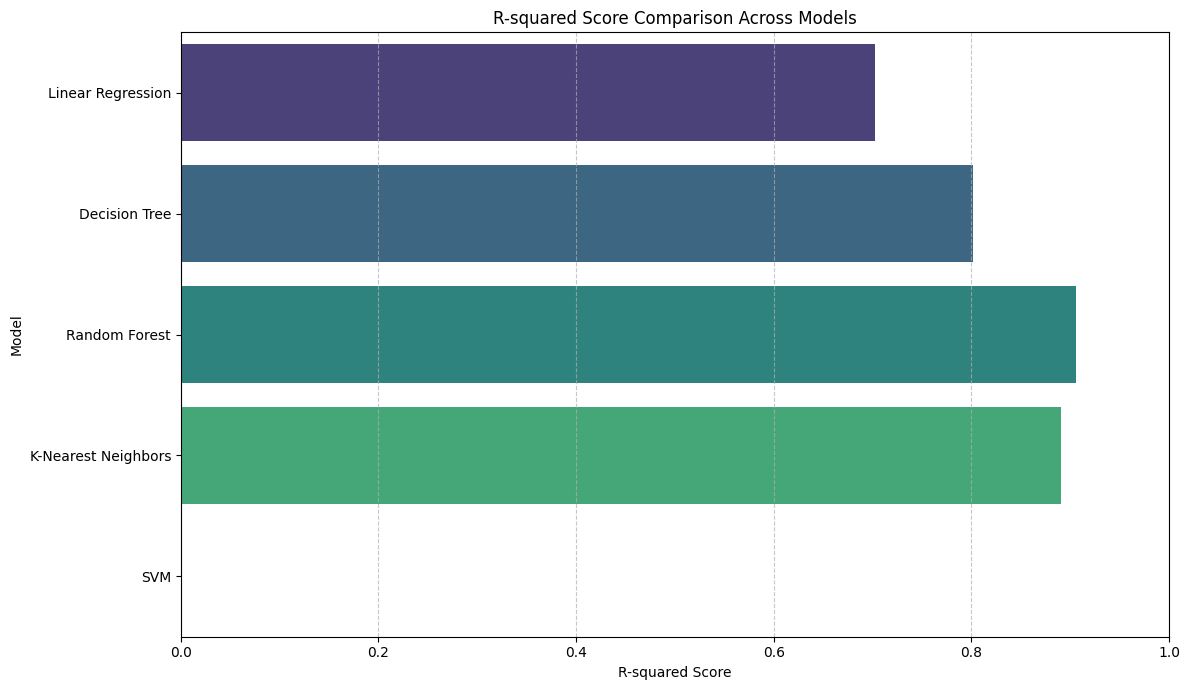

In [22]:
# Visualize R-squared scores
plt.figure(figsize=(12, 7))
sns.barplot(x='R2 Score', y='Model', data=performance_df, palette='viridis')
plt.title('R-squared Score Comparison Across Models')
plt.xlabel('R-squared Score')
plt.ylabel('Model')
plt.xlim(0, 1) # R-squared typically ranges from 0 to 1 for good models
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Model Performance Comparison

In [23]:
# Display the performance DataFrame to compare R-squared scores
display(performance_df)

,Model,R2 Score
0,Linear Regression,0.702909
1,Decision Tree,0.801523
2,Random Forest,0.906352
3,K-Nearest Neighbors,0.890520
4,SVM,-0.004252


As you can see, the **Random Forest** model has the highest R-squared score, indicating it explains the most variance in the `Salary` target variable among the models tested. **K-Nearest Neighbors** also shows strong performance. The **SVM** model performed poorly, suggesting it might require more specific tuning or a different approach for this dataset. The bar chart above provides a visual representation of this comparison.

In [24]:
import pickle

# Define the filename for the saved model
model_filename = 'random_forest_regressor_best_model.pkl'

# Save the best model (Random Forest Regressor) to a .pkl file
with open(model_filename, 'wb') as file:
    pickle.dump(random_forest_model, file)

print(f"Best model (Random Forest Regressor) saved to {model_filename}")

Best model (Random Forest Regressor) saved to random_forest_regressor_best_model.pkl
